# Hull-White CCR Model Validation

The baseline engine uses Hull-White 1F to simulate future short-rate states, revalue a fixed-for-floating IRS, generate EE/PFE exposure profiles, and compute unilateral CVA.

The purpose of this notebook is to distinguish:

- implementation error,
- Monte Carlo sampling error,
- numerical/discretisation error,
- model/parameter uncertainty,

and quantify their propagation in EE, PFE and CVA.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from ccr_validation.curves import DiscountCurve
from ccr_validation.swaps import InterestRateSwap
from ccr_validation.hull_white import HullWhite1F
from ccr_validation.exposure import exposure_profile
from ccr_validation.cva import (ConstantHazardCreditModel, unilateral_cva)

import matplotlib.pyplot as plt

plt.style.use("bmh")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True,
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

In [2]:
# set all relevant parameters required for modelling
times = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
discount_factors = [1.0, 0.981, 0.960, 0.918, 0.875, 0.795]

curve = DiscountCurve(times, discount_factors)

swap = InterestRateSwap(
    notional=10_000_000,
    fixed_rate=0.04,
    maturity=5.0,
    payments_per_year=2,
    pay_fixed=True,
)

hw = HullWhite1F(
    curve=curve, 
    a=0.1, 
    sigma=0.01
)

credit = ConstantHazardCreditModel(
    hazard_rate=0.02, 
    recovery_rate=0.40
)

profile = exposure_profile(
    swap=swap,
    model=hw,
    n_paths=100_000,
    seed=42,
)

cva = unilateral_cva(
    times=profile["times"],
    discounted_ee=profile["discounted_ee"],
    credit_model=credit,
)

## Exact transition vs Euler-Maruyama

### Validation question

How large is the discretisation bias from Euler-Maruyama, and how does it propagate into EE, PFE and CVA?

The Hull–White state $x_t$ is an OU process with mean reversion $a$ and volatility $\sigma_{\mathrm{HW}}$. Its exact and Euler steps are

$$
x_{t+\Delta t}=e^{-a\Delta t}x_t
+\sigma_{\mathrm{HW}}\sqrt{\frac{1-e^{-2a\Delta t}}{2a}}\,Z,
$$

$$
x_{t+\Delta t}^{\mathrm{Euler}}
=(1-a\Delta t)x_t^{\mathrm{Euler}}
+\sigma_{\mathrm{HW}}\sqrt{\Delta t}\,Z,
$$

where $Z$ is a standard normal draw. With $x_0=0$, both have zero mean. At $t=\ell\Delta t$, their analytical variances are

$$
\begin{aligned}
\operatorname{Var}^{\mathbb Q}(x_t)
&=\frac{\sigma_{\mathrm{HW}}^2}{2a}(1-e^{-2at}),\\
\operatorname{Var}^{\mathbb Q}(x_t^{\mathrm{Euler}})
&=\sigma_{\mathrm{HW}}^2\Delta t\frac{1-\rho_{\mathrm E}^{2\ell}}{1-\rho_{\mathrm E}^2},
\qquad \rho_{\mathrm E}=1-a\Delta t.
\end{aligned}
$$

The simulation results below are compared with these benchmarks.

In [3]:
# simulation parameters
T = 5.0
n_paths = 100_000
dts = [1.0, 0.5, 0.25, 0.1, 0.05]

### Findings

In [4]:
exact_variance = (
    hw.sigma**2 / (2.0 * hw.a) * (1.0 - np.exp(-2.0 * hw.a * T))
    )

results = []

for dt in dts:
    times = np.arange(0.0, T + dt / 2, dt)
    n_steps = len(times) - 1

    # Same seed -> same underlying Z draws
    exact_paths = hw.simulate_x_paths(
        times=times,
        n_paths=n_paths,
        seed=42,
    )

    euler_paths = hw.simulate_x_paths_euler(
        times=times,
        n_paths=n_paths,
        seed=42,
    )

    exact_mc_var = np.var(exact_paths[:, -1], ddof=1)
    euler_mc_var = np.var(euler_paths[:, -1], ddof=1)

    rho_e = 1.0 - hw.a * dt
    euler_analytic_var = (
        hw.sigma**2 * dt * (1.0 - rho_e**(2 * n_steps)) / (1.0 - rho_e**2)
    )

    results.append({
        "dt": dt,
        "exact_MC_var": exact_mc_var,
        "euler_MC_var": euler_mc_var,
        "euler_analytic_var": euler_analytic_var,
        "exact_analytic_var": exact_variance,
        "euler_bias_pct": (
            100.0
            * (euler_analytic_var - exact_variance)
            / exact_variance
        ),
    })

df = pd.DataFrame(results)
df

,dt,exact_MC_var,euler_MC_var,euler_analytic_var,exact_analytic_var,euler_bias_pct
0,1.00,0.000318,0.000344,0.000343,0.000316,8.460583
1,0.50,0.000319,0.000332,0.000329,0.000316,4.088239
2,0.25,0.000317,0.000324,0.000322,0.000316,2.010273
3,0.10,0.000318,0.000320,0.000319,0.000316,0.796188
4,0.05,0.000316,0.000318,0.000317,0.000316,0.396790


The exact simulator reproduces the analytical Hull-White variance independently of the simulation timestep.

Euler-Maruyama reproduces its own analytical discrete-time variance, confirming implementation correctness, but exhibits a positive discretisation bias relative to the exact process.

The variance bias decreases approximately linearly with $\Delta t$, consistent with $\mathcal O(\Delta t)$ convergence.

For example:

| $\Delta t$ | Euler variance bias |
|---:|---:|
| 1.00 | 8.46% |
| 0.50 | 4.09% |
| 0.25 | 2.01% |
| 0.10 | 0.80% |
| 0.05 | 0.40% |

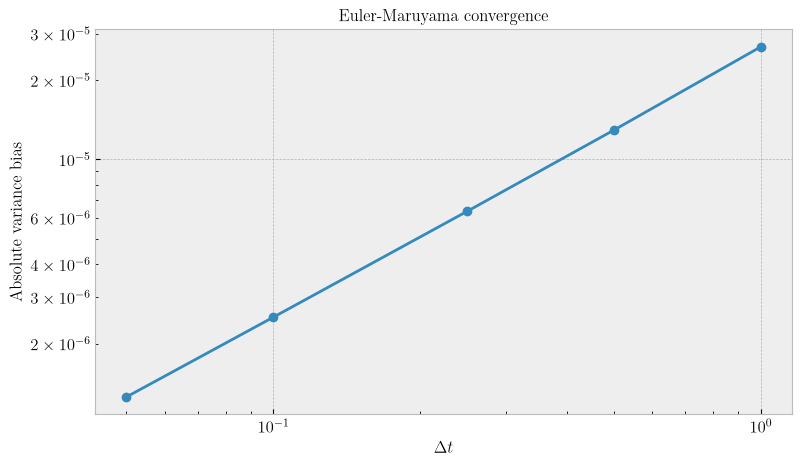

In [5]:
bias = np.abs(df["euler_analytic_var"] - df["exact_analytic_var"])

plt.loglog(df["dt"], bias, "o-")
plt.xlabel(r"$\Delta t$")
plt.ylabel("Absolute variance bias")
plt.title("Euler-Maruyama convergence")
plt.grid(True)
plt.show()

## Impact on exposure

In [6]:
exact = exposure_profile(
    swap,
    hw,
    n_paths=100_000,
    seed=42,
    simulation_method="exact",
    simulation_dt=0.5,
)

euler = exposure_profile(
    swap,
    hw,
    n_paths=100_000,
    seed=42,
    simulation_method="euler",
    simulation_dt=0.5,
)

def curve_bias_pct(candidate, benchmark):
    return (
        100.0 * np.sum(np.abs(candidate - benchmark)) / np.sum(np.abs(benchmark))
    )


results = []

dts = [0.5, 0.25, 0.1, 0.05]

for dt in dts:
    exact = exposure_profile(
        swap=swap,
        model=hw,
        n_paths=100_000,
        seed=42,
        simulation_method="exact",
        simulation_dt=dt,
    )

    euler = exposure_profile(
        swap=swap,
        model=hw,
        n_paths=100_000,
        seed=42,
        simulation_method="euler",
        simulation_dt=dt,
    )

    results.append({
        "dt": dt,
        "EE_bias_pct": curve_bias_pct(
            euler["ee"], exact["ee"]
        ),
        "PFE95_bias_pct": curve_bias_pct(
            euler["pfe_95"], exact["pfe_95"]
        ),
        "PFE99_bias_pct": curve_bias_pct(
            euler["pfe_99"], exact["pfe_99"]
        ),
    })

exposure_convergence = pd.DataFrame(results)
exposure_convergence

,dt,EE_bias_pct,PFE95_bias_pct,PFE99_bias_pct
0,0.50,0.597158,1.423337,1.574462
1,0.25,0.294807,0.704562,0.778526
2,0.10,0.116967,0.279814,0.305466
3,0.05,0.058331,0.139710,0.153964


For each of the $N$ simulated paths, exposure is the positive swap value, $E_t^{(j)}=(V_t^{(j)})^+$. The reported risk-neutral mean and quantile are

$$
\operatorname{EE}^{\mathbb Q}(t)\approx\frac{1}{N}\sum_{j=1}^{N}E_t^{(j)},
\qquad
\operatorname{PFE}^{\mathbb Q}_q(t)=\operatorname{Quantile}^{\mathbb Q}_q(E_t).
$$

Using common random numbers for the exact and Euler simulations, the state-variable discretisation bias was propagated through bond pricing and swap revaluation into EE and PFE.

| $\Delta t$ | EE bias | PFE95 bias | PFE99 bias |
|---:|---:|---:|---:|
| 0.50 | 0.60% | 1.42% | 1.57% |
| 0.25 | 0.29% | 0.70% | 0.78% |
| 0.10 | 0.12% | 0.28% | 0.31% |
| 0.05 | 0.06% | 0.14% | 0.15% |

The downstream exposure error also decreases approximately as $\mathcal O(\Delta t)$.

Tail exposure is more sensitive to the discretisation error than mean exposure: PFE95/PFE99 biases are consistently larger than EE bias.

## Impact on CVA

In [7]:
results = []

for dt in dts:
    exact = exposure_profile(
        swap=swap,
        model=hw,
        n_paths=100_000,
        seed=42,
        simulation_method="exact",
        simulation_dt=dt,
    )

    euler = exposure_profile(
        swap=swap,
        model=hw,
        n_paths=100_000,
        seed=42,
        simulation_method="euler",
        simulation_dt=dt,
    )

    exact_cva = unilateral_cva(
        times=exact["times"],
        discounted_ee=exact["discounted_ee"],
        credit_model=credit,
    )

    euler_cva = unilateral_cva(
        times=euler["times"],
        discounted_ee=euler["discounted_ee"],
        credit_model=credit,
    )

    results.append({
        "dt": dt,
        "exact_CVA": exact_cva,
        "euler_CVA": euler_cva,
        "CVA_bias": euler_cva - exact_cva,
        "CVA_bias_pct": 100.0 * (euler_cva - exact_cva) / exact_cva,
    })

cva_convergence = pd.DataFrame(results)
cva_convergence

,dt,exact_CVA,euler_CVA,CVA_bias,CVA_bias_pct
0,0.50,10380.731141,10446.176924,65.445783,0.630454
1,0.25,10392.474559,10424.794881,32.320321,0.310997
2,0.10,10407.319129,10420.157312,12.838182,0.123357
3,0.05,10416.401722,10422.810784,6.409062,0.061529


CVA uses exposure discounted along the same simulated path. With survival $Q(t)=e^{-\gamma t}$ and $\mathrm{LGD}=1-\mathrm{REC}$,

$$
\operatorname{DEE}^{\mathbb Q}(t)=\mathbb E^{\mathbb Q}[D(0,t)V_t^+],
$$

$$
\mathrm{CVA}_0\approx\mathrm{LGD}\sum_{k=1}^{m}
\operatorname{DEE}^{\mathbb Q}(u_k)[Q(u_{k-1})-Q(u_k)].
$$

Here $u_k$ are exposure dates, $D(0,t)$ discounts from time $t$ to today, and $Q(t)$ is the survival probability under the risk-neutral measure $\mathbb Q$. Independent default separates the default weights; discounting and exposure remain dependent.

Within each row, the exact and Euler simulators share the grid and Gaussian draws. Across grids, a common seed does not produce identical Brownian paths, so absolute CVA variation mixes integration and sampling effects.

### Validation conclusion

The Euler-Maruyama implementation is internally correct but introduces predictable $\mathcal O(\Delta t)$ discretisation bias.

For the parameters and trade considered here:

- state variance is more sensitive to Euler discretisation than the final exposure metrics,
- EE is relatively insensitive,
- tail exposure is more sensitive than EE,
- CVA inherits a smaller but systematic bias,
- reducing $\Delta t$ produces the expected convergence.

Because Hull-White 1F admits an exact OU transition, there is little numerical justification for using Euler-Maruyama for this process when the exact transition is available.

This experiment therefore serves primarily as validation hygiene and establishes the candidate-versus-benchmark methodology used in subsequent model-risk investigations.

## Side investigation: exposure-grid coarsening

In [8]:
exact = exposure_profile(
    swap=swap,
    model=hw,
    n_paths=200_000,
    seed=42,
    simulation_method="exact",
    simulation_dt=0.5,
)

In [9]:
grid_steps = [1, 2, 4]   # 0.5y, 1.0y, 2.0y

results = []

for step in grid_steps:
    idx = np.arange(0, len(exact["times"]), step)

    # Always include maturity
    if idx[-1] != len(exact["times"]) - 1:
        idx = np.append(idx, len(exact["times"]) - 1)

    times_sub = exact["times"][idx]
    discounted_ee_sub = exact["discounted_ee"][idx]

    cva = unilateral_cva(
        times=times_sub,
        discounted_ee=discounted_ee_sub,
        credit_model=credit,
    )

    results.append({
        "grid_years": 0.5 * step,
        "n_exposure_dates": len(times_sub),
        "CVA": cva,
    })

grid_df = pd.DataFrame(results)

benchmark_cva = grid_df.loc[
    grid_df["grid_years"] == 0.5, "CVA"
].iloc[0]

grid_df["CVA_bias"] = grid_df["CVA"] - benchmark_cva
grid_df["CVA_bias_pct"] = 100.0 * grid_df["CVA_bias"] / benchmark_cva

grid_df

,grid_years,n_exposure_dates,CVA,CVA_bias,CVA_bias_pct
0,0.5,11,10388.040776,0.000000,0.000000
1,1.0,6,9493.762759,-894.278017,-8.608726
2,2.0,4,8085.941455,-2302.099321,-22.161054


The table above samples the **same discounted-exposure paths** at progressively coarser payment-date grids. Differences therefore reflect default-time quadrature rather than new Monte Carlo draws.

This is a diagnostic on a semiannual-pay, 5Y trade and deliberately retains only coupon dates. The current engine supports between-payment OIS accrual and arbitrary exposure dates; it is no longer restricted to reset-date valuation. Notebook 05 separately compares monthly, semimonthly, weekly and half-weekly exposure sampling for the 10Y reference trade using a common fine simulation.

The right-endpoint sum can miss exposure immediately before coupon payments. Its convergence must be checked independently from short-rate/accrual integration.

In [10]:
results_path = Path("../results")

results_path.mkdir(parents=True, exist_ok=True)

for name, table in {
    "hw_euler_state_variance": df,
    "hw_euler_exposure_convergence": exposure_convergence,
    "hw_euler_cva_convergence": cva_convergence,
    "hw_payment_date_grid_coarsening": grid_df,
}.items():
    table.to_csv(results_path / f"{name}.csv", index=False)